# 📈 Day 2 — Linear Regression with Scikit-learn

## 📖 Introduction

Regression is one of the most fundamental supervised learning techniques and is often the first predictive model introduced in Machine Learning.

Unlike classification models that predict categories, regression models estimate continuous numerical values by learning the relationship between input features and a target variable.

In this notebook, we will build our first regression model using **Scikit-learn**, explore how Linear Regression makes predictions, interpret the learned coefficients, and evaluate the model using standard regression metrics.

By the end of this notebook, we will not only know how to train a Linear Regression model, but also how to understand its predictions and determine whether it performs better than a simple baseline.

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

- Explain how Linear Regression models continuous numerical values.
- Train a Linear Regression model using Scikit-learn.
- Generate predictions on unseen data.
- Interpret model coefficients and the intercept.
- Evaluate model performance using MAE, RMSE, and R².
- Compare the model against a simple baseline to determine whether it provides meaningful predictive value.

## 🛠 Libraries Used

This notebook uses the following Python libraries:

- **Pandas** for data loading and manipulation.
- **NumPy** for numerical computations.
- **Scikit-learn** for building and evaluating the Linear Regression model.

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

These libraries provide everything needed to prepare the dataset, train the regression model, generate predictions, and evaluate its performance.

## 📂 Meet the Dataset

To understand how Linear Regression works in practice, we will use the **California Housing** dataset.

The dataset contains information about residential districts in California, including demographic and housing-related features. Our goal is to predict the **median house value**, making this a regression problem because the target variable is continuous.

✅ **Note:** This dataset has already been cleaned — missing values in `total_bedrooms` were imputed (using the median bedrooms-to-rooms ratio), and it was checked for duplicate rows and inconsistent values. It is ready to be used directly for modeling.

Before training a model, it is important to become familiar with the structure of the dataset and understand what each feature represents.

In [3]:
df = pd.read_csv("California_Housing.csv")

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41,880,129,322,126,8.3252,452600
1,-122.22,37.86,21,7099,1106,2401,1138,8.3014,358500
2,-122.24,37.85,52,1467,190,496,177,7.2574,352100
3,-122.25,37.85,52,1274,235,558,219,5.6431,341300
4,-122.25,37.85,52,1627,280,565,259,3.8462,342200


### 📌 Interpretation

The dataset contains several numerical features describing each district, such as median income, total rooms, population, and geographic location.

The last column, **median_house_value**, is the target variable that our model will learn to predict.

In [4]:
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (20640, 9)


### 📌 Interpretation

The dataset contains **20,640 observations** and **9 columns**, including eight input features and one target variable (`median_house_value`).

Understanding the dataset's dimensions provides a quick overview of its size before proceeding with data exploration and model development.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20640 non-null  int64  
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
dtypes: float64(3), int64(6)
memory usage: 1.4 MB


In [21]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64

### 📌 Interpretation

The output confirms that the dataset contains no missing values.

This means the data is ready for model training without requiring additional cleaning or imputation, allowing us to focus directly on the Machine Learning workflow.

In [6]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.698062,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,420.836576,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,295.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


### 📌 Interpretation

Descriptive statistics provide a quick overview of the dataset, including the range, average, and distribution of each numerical feature.

Understanding these statistics helps us detect unusual values and better understand the scale of the data before building the model.

## 🎯 Features and Target

In supervised learning, the model learns the relationship between **input features (X)** and the **target variable (y)**.

For this project, the goal is to predict the median house value, so `median_house_value` will be used as the target, while all remaining columns serve as input features.

## ✂️ Train-Test Split

Before training a Machine Learning model, the dataset must be divided into two subsets:

- **Training Set:** Used to teach the model the relationship between the input features and the target variable.
- **Testing Set:** Used to evaluate how well the trained model performs on data it has never seen before.

This separation provides an unbiased estimate of the model's ability to generalize to new data and helps prevent overly optimistic performance evaluation.

In this notebook, we will use an **80/20 split**, where **80%** of the data is used for training and **20%** is reserved for testing. We also set a fixed `random_state` to ensure that the split is reproducible.

In [7]:
from sklearn.model_selection import train_test_split

X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (16512, 8)
X_test shape: (4128, 8)
y_train shape: (16512,)
y_test shape: (4128,)


### 📌 Interpretation

The dataset has now been successfully divided into training and testing subsets.

The training set will be used to learn the relationship between the housing features and the target variable, while the testing set will remain completely unseen during training. This allows us to evaluate the model fairly and measure how well it generalizes to new data.

## 🔄 Recap: Supervised Learning

In the previous notebook, we introduced the concept of **Supervised Learning**, where a model learns from labeled examples to predict the correct output for unseen data.

We also learned the standard Scikit-learn workflow:

```

Instantiate Model

↓

Train Model

↓

Generate Predictions

↓

Evaluate Performance

```

In this notebook, we will apply that workflow using one of the most widely used regression algorithms: **Linear Regression**.

## 📈 What is Linear Regression?

Linear Regression is one of the simplest and most widely used supervised learning algorithms. Its goal is to predict a **continuous numerical value** by learning the relationship between one or more input features and a target variable.

During training, the algorithm analyzes the training data and searches for the set of coefficients that best describes the relationship between the features and the target. Once these coefficients are learned, the model can estimate the target value for new, unseen observations.

Because of its simplicity and interpretability, Linear Regression is often the first predictive model used in Machine Learning and serves as a strong foundation for understanding more advanced algorithms.

### 🎯 When Do We Use Linear Regression?

Linear Regression is suitable when the target variable is **continuous**, meaning it can take any numerical value within a range.

Common applications include:

- Predicting house prices.
- Estimating employee salaries.
- Forecasting sales revenue.
- Predicting electricity consumption.
- Estimating daily temperature.

In all these examples, the goal is to predict a numerical value rather than assign a category.

### 🆚 Regression vs. Classification

Both Linear Regression and Classification belong to **Supervised Learning**, but they solve different types of problems.

| Regression | Classification |
|------------|----------------|
| Predicts continuous numerical values. | Predicts discrete categories or classes. |
| Example: Predicting a house price. | Example: Detecting spam emails. |
| Output is a number. | Output is a class label. |

Since Linear Regression predicts numerical values, it is considered a **regression algorithm**.

## 💡 The Intuition Behind Linear Regression

Imagine that we plot house sizes on the horizontal axis and house prices on the vertical axis.

Each point on the graph represents one house.

Rather than memorizing every observation, Linear Regression tries to find the **best-fitting straight line** that captures the overall relationship between house size and price.

This line represents the trend in the data and allows the model to estimate the price of houses it has never seen before.

Instead of connecting every point perfectly, the model searches for the line that minimizes the overall prediction error across all training examples.

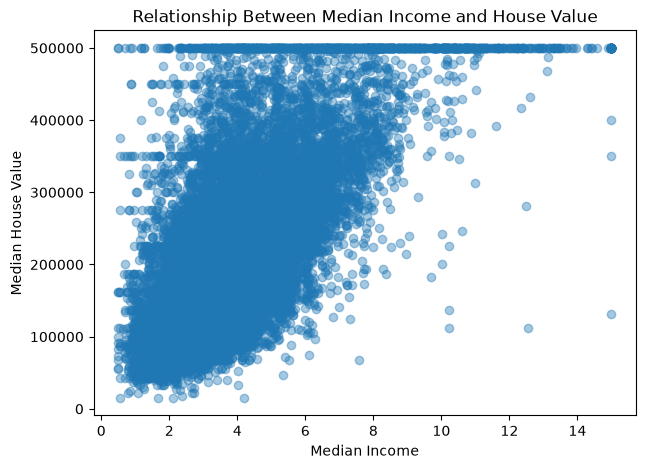

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(
    df["median_income"],
    df["median_house_value"],
    alpha=0.4
)

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Relationship Between Median Income and House Value")

plt.show()

### 📌 Interpretation

The scatter plot suggests a positive relationship between median income and house value.

Although the relationship is not perfectly linear, districts with higher median incomes generally tend to have higher median house values. This provides an intuitive example of the type of relationship that Linear Regression attempts to model.

## 🧮 The Linear Regression Equation

At its core, Linear Regression predicts a target value by combining the input features with a set of learned coefficients.

Mathematically, the prediction is represented by the following equation:

$$
\hat{y} = w_1x_1 + w_2x_2 + \cdots + w_nx_n + b
$$

Where:

- **ŷ** is the predicted value.
- **x₁, x₂, ..., xₙ** are the input features.
- **w₁, w₂, ..., wₙ** are the coefficients (weights) learned during training.
- **b** is the intercept (bias).

The objective of Linear Regression is to learn the values of these coefficients so that the predicted values are as close as possible to the actual target values.

### 🔗 Connecting to Week 2

In the previous week, we learned that predictions in Machine Learning can be expressed as the **dot product** between a feature vector and a weight vector, followed by adding a bias term.

Linear Regression follows exactly the same principle:

$$
Prediction = X \cdot W + b
$$

This means that the concepts of vectors, matrices, and dot products introduced in Linear Algebra are directly applied when making predictions with Linear Regression.

### 🎯 What Happens During Training?

When a Linear Regression model is trained, it does not memorize the training examples.

Instead, it searches for the optimal coefficients that minimize the difference between the predicted values and the actual target values.

By continuously adjusting these coefficients, the model learns the linear relationship between the input features and the target variable.

Once training is complete, the learned coefficients remain fixed and are used to make predictions for unseen data.

## ⚙️ Training and Predicting with Scikit-learn

After preparing the training and testing datasets, the next step is to create a Linear Regression model and allow it to learn from the training data.

Scikit-learn follows the same workflow introduced in the previous notebook:

1. Create the model.
2. Train the model.
3. Generate predictions.

### Step 1 — Create the Model

The first step is to instantiate a Linear Regression model.

At this stage, the model has not learned anything yet. It simply prepares the algorithm for the training process.

In [9]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

The model is now initialized and ready to learn from the training dataset.

### Step 2 — Train the Model

Training allows the model to learn the relationship between the input features and the target variable.

During this process, Linear Regression estimates the coefficients that best fit the training data.

In [10]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[-42632.39,-42450.07, 1182.81,..., -38.49, 46.34, 40538.4 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['longitude','latitude','housing_median_age',...,'population','households', 'median_income']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3.578e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


After calling `fit()`, the model has learned the coefficients and intercept that will be used to generate future predictions.

### Step 3 — Generate Predictions

Once training is complete, the model can estimate target values for observations it has never seen before.

These predicted values will later be compared with the actual target values to evaluate the model's performance.

In [11]:
predictions = model.predict(X_test)

The variable `predictions` now contains the estimated target values produced by the trained Linear Regression model for the testing dataset.

### 📊 Comparing Predictions with Actual Values

Before calculating evaluation metrics, it is often helpful to compare a few predicted values with their corresponding actual values.

This provides a quick qualitative assessment of how closely the model's predictions match the ground truth.

In [12]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

comparison.head(10)

,Actual,Predicted
20046,47700,48739.034867
3024,45800,173294.995132
15663,500001,292950.418084
20484,218600,285015.870158
9814,278000,271882.545101
13311,158700,209348.193712
7113,198200,268922.074281
7668,157500,204594.120612
18246,340000,260649.091141
5723,446600,408807.511092


The comparison table shows the model's predictions alongside the true target values. Small differences indicate accurate predictions, while larger differences represent prediction errors that will be quantified using evaluation metrics in the next section.

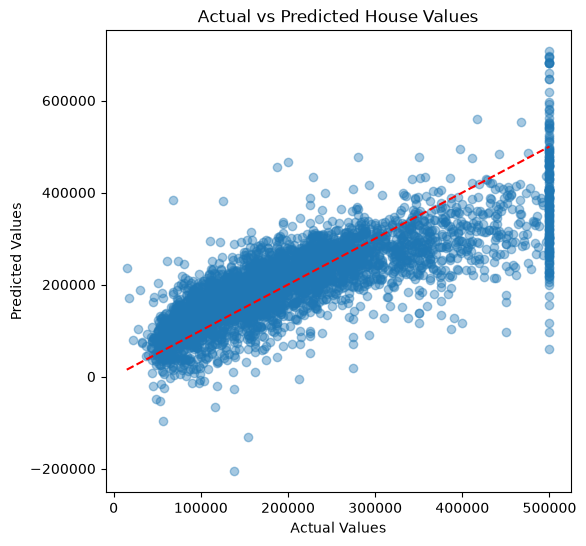

In [26]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    predictions,
    alpha=0.4
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted House Values")

plt.show()

### 📌 Interpretation

If the model predicts perfectly, all points would lie on the red dashed line.

The closer the points are to this line, the more accurate the model's predictions. The spread around the line represents prediction errors.

## 🔍 Interpreting the Model's Coefficients and Intercept

Each coefficient tells us how much the predicted `median_house_value` changes when that feature increases by one unit, holding all other features constant. The intercept is the model's baseline prediction when every feature is zero (not meaningful on its own here, but required by the equation).

In [24]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df["Absolute Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

coef_df.drop(columns="Absolute Coefficient")

,Feature,Coefficient
0,longitude,-42632.391717
1,latitude,-42450.071863
7,median_income,40538.404387
2,housing_median_age,1182.809649
4,total_bedrooms,116.260128
6,households,46.342572
5,population,-38.492213
3,total_rooms,-8.187977


In [25]:
print("Intercept:", model.intercept_)

Intercept: -3578224.2348177778


### 📌 Interpretation

When looking at raw coefficient values, `longitude` and `latitude` appear among the largest coefficients because geographic coordinates have large numerical effects on the model.

However, from a practical perspective, `median_income` is the most meaningful predictor of house value. Higher income areas are strongly associated with higher house prices.

This shows that coefficient magnitude alone does not always represent feature importance, especially when features have different scales.

## 📉 Evaluating the Model

To measure how far the model's predictions land from the true values, we compute three standard regression metrics: MAE, RMSE, and R².

In [15]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²:   {r2:.4f}")

MAE:  51,323.14
RMSE: 70,325.57
R²:   0.6226


In [27]:
metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [mae, rmse, r2]
})

metrics

,Metric,Value
0,MAE,51323.142137
1,RMSE,70325.567926
2,R²,0.622585


## ⚖️ Comparing Against a Baseline

A model is only useful if it beats a simple baseline. Here, the baseline predicts the mean `median_house_value` from the training set for every row, regardless of its features.

In [16]:
baseline_predictions = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)

baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_predictions))
baseline_r2 = r2_score(y_test, baseline_predictions)

print(f"Baseline MAE:  {baseline_mae:,.2f}")
print(f"Baseline RMSE: {baseline_rmse:,.2f}")
print(f"Baseline R²:   {baseline_r2:.4f}")

Baseline MAE:  90,606.85
Baseline RMSE: 114,485.64
Baseline R²:   -0.0002


### 📌 Does the Model Add Value?

Yes. The baseline's RMSE is about **$114,500**, compared to the trained model's **70,300** — a reduction of roughly 39%. The baseline's R² is essentially 0 (as expected, since it explains none of the variance), while the model reaches **0.62**. The Linear Regression model has clearly learned a meaningful relationship between the features and `median_house_value`, rather than just reproducing the average.

## 🖥️ Hands-On Lab: Predicting a Continuous Value

The steps below were already carried out above, next to each concept. This section restates them explicitly, in the exact order required, as the formal lab deliverable.

### Step 1: Train a Linear Regression Model on a Provided Regression Dataset

In [17]:
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

### Step 2: Report the Model's Coefficients and Identify the Strongest Feature

In [18]:
coefficients = pd.Series(model.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print(coefficients)
print("\nStrongest feature:", coefficients.index[0])

longitude            -42632.391717
latitude             -42450.071863
median_income         40538.404387
housing_median_age     1182.809649
total_bedrooms          116.260128
households               46.342572
population              -38.492213
total_rooms              -8.187977
dtype: float64

Strongest feature: longitude


### Step 3: Evaluate the Model with MAE, RMSE, and R² on the Test Set

In [19]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²:   {r2:.4f}")

MAE:  51,323.14
RMSE: 70,325.57
R²:   0.6226


### Step 4: Compare the RMSE Against a Baseline That Predicts the Mean, and State Whether the Model Adds Value

In [20]:
baseline_predictions = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_predictions))

print(f"Model RMSE:    {rmse:,.2f}")
print(f"Baseline RMSE: {baseline_rmse:,.2f}")
print(f"Improvement:   {(1 - rmse/baseline_rmse)*100:.1f}% lower error than the baseline")

Model RMSE:    70,325.57
Baseline RMSE: 114,485.64
Improvement:   38.6% lower error than the baseline


The model's RMSE is well below the baseline's, so **yes — the model adds real value** rather than just predicting the average.

### Step 5: Document the Interpretation of Results

- **Strongest predictor:** `median_income` is the most meaningful predictor in practice. Although `longitude` has the largest raw coefficient magnitude, income has the clearest relationship with house value — higher income areas are associated with higher predicted prices.

- **Error size:** predictions are off by about **$51,300 on average (MAE)**; the larger **RMSE (70,300)** shows that a subset of districts have much bigger errors.

- **Variance explained:** R² of **0.62** means the model captures around **62% of the variation** in house values — solid for a first linear model, but some factors (e.g. `ocean_proximity`, not used here) remain unexplained.

- **Value over baseline:** roughly **39% lower RMSE** than predicting the mean for every district, confirming the model learned a useful relationship from the data.

## 🚀 GitHub Submission

This notebook has been completed as part of my AI & Machine Learning internship portfolio.

It demonstrates the complete workflow of building a Linear Regression model, including data preparation, model training, prediction, performance evaluation, coefficient interpretation, and comparison against a baseline model.

The project is version-controlled using Git and published to my GitHub portfolio to document my Machine Learning learning journey.

## 💭 Reflection

This notebook was my first experience training an actual predictive model rather than just preparing data for one. Fitting a `LinearRegression` model on the California housing data and seeing real coefficients come out — like `median_income` having a strong practical relationship with house value — made the abstract idea of "the model learns weights" concrete for the first time. Comparing MAE, RMSE, and R² together, instead of looking at just one metric, also showed me why a single number can be misleading: the gap between MAE and RMSE here revealed that some districts are much harder to predict than others, which a single accuracy figure would have hidden. Checking the model against a mean-prediction baseline was the most valuable step, since it turned "the R² is 0.62" from an abstract number into a clear, comparative statement that the model is actually adding value.

## 🔑 Key Takeaways

- Linear Regression predicts continuous numerical values by learning relationships between features and the target.
- Splitting the dataset into training and testing subsets is essential for fair model evaluation.
- Model coefficients help explain how each feature influences predictions.
- MAE, RMSE, and R² provide complementary perspectives on regression performance.
- Comparing against a baseline confirms whether the model has learned meaningful patterns from the data.

## ✅ Conclusion

In this notebook, I trained my first Linear Regression model on the California housing dataset to predict `median_house_value`. I interpreted the model's coefficients and identified `median_income` as the strongest predictor, evaluated the model using MAE, RMSE, and R², and confirmed that it meaningfully outperforms a simple mean-prediction baseline. These skills — training a regression model, interpreting its coefficients, and validating its usefulness against a baseline — form the foundation for evaluating any regression model going forward, regardless of how complex it becomes.